# ZZ-dephasing noise-resilience sweep

This notebook benchmarks the **ZZ dephasing time-evolution workflow** under a one-parameter hardware-noise sweep.

For each sweep point, it reports:
- mean fidelity over the time grid,
- mean effective success probability over the time grid,
- mean Frobenius distance over the time grid.

The effective success probability here is the **average retained-shot fraction across the executed Kraus-branch runs**.


In [31]:
import sys
from pathlib import Path
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

project_root = os.path.abspath('../..')
if project_root not in sys.path:
    sys.path.insert(0, project_root)


from timeevo.ZZ.zz_dephasing import (
    ket_plus,
    paper_time_grid,
    exact_zz_dephasing_density_matrix,
    simulate_zz_dephasing_kraus_branch,
    simulate_zz_dephasing_branch_via_method
)
from noise.noise_simulation import (
    SimpleNISQNoiseParameters,
    noisy_single_qubit_measurement,
)
from noise.noise_resilience_common import (
    NoiseSweepSpecification,
    linear_sweep,
    log_sweep,
    run_noise_resilience_sweep,
)
from metric.success_probability import success_probability_from_counts, method_comparison_success_probability

from plot.noise_sweep_plot import (
    default_sweep_xlabel,
    plot_method_comparison_dataframe,
    SweepPlotColumns,
)

from metric.fidelity_frobenius import evaluate_fidelity_frobenius



## Configuration

In [32]:
# ----------------------
# Sweep configuration
# ----------------------
noise_kind = 'amplitude_damping'  # 'amplitude_damping', 'phase_damping', 'depolarizing', 'readout'
parameterization = 'probability'  # 'probability' for all; 'rate' also works for amplitude/phase damping
sweep_values = linear_sweep(0.0, 0.20, 9)
# sweep_values = log_sweep(1e-3, 2e-1, 8)  # alternative

# ----------------------
# Methods to compare
# ----------------------
methods = ['paper_svd', 'sz_nagy', 'unitary_rescaled']

# For the unitary-only baseline:
# - False -> plot a flat success-probability line at 1.0
# - True  -> store success probability as NaN
unitary_baseline_as_nan = False
unitary_baseline_success_value = 1.0

# ----------------------
# ZZ channel parameters
# ----------------------
theta = 0.05
lambda0 = 0.7
lambda1 = 0.3
initial_state = ket_plus()
times = paper_time_grid(theta=theta, periods=1.0, num_points=21)

# ----------------------
# Experiment size
# ----------------------
repeats = 3
shots_ancilla = 4000
shots_tomography = 4000
rng_seed = 20260415

# ----------------------
# Noise-model baseline
# ----------------------
base_noise_params = SimpleNISQNoiseParameters(
    t1_system=np.inf,
    t2_system=np.inf,
    t1_ancilla=np.inf,
    t2_ancilla=np.inf,
    one_qubit_gate_time=1.0,
    two_qubit_gate_time=1.0,
    p1q_depolarizing=0.0,
    p2q_depolarizing=0.0,
    readout_p0_to_1_system=0.0,
    readout_p1_to_0_system=0.0,
    readout_p0_to_1_ancilla=0.0,
    readout_p1_to_0_ancilla=0.0,
)

# ----------------------
# Sweep-spec options
# ----------------------
spec = NoiseSweepSpecification(
    noise_kind=noise_kind,
    sweep_values=sweep_values,
    parameterization=parameterization,
    duration=base_noise_params.two_qubit_gate_time,
    isolate_noise=True,
    apply_to='both',
    depolarizing_mode='both',
    symmetric_readout=True,
)

print('Time points:', len(times))
print('Sweep points:', len(sweep_values))
print('Methods:', methods)

Time points: 21
Sweep points: 9
Methods: ['paper_svd', 'sz_nagy', 'unitary_rescaled']


## Helper functions used only in this notebook

In [33]:
def hermitize(rho: np.ndarray) -> np.ndarray:
    rho = np.asarray(rho, dtype=complex)
    return 0.5 * (rho + rho.conj().T)


def safe_nanmean(values) -> float:
    arr = np.asarray(values, dtype=float)
    if arr.size == 0 or np.all(~np.isfinite(arr)):
        return float(np.nan)
    return float(np.nanmean(arr))


def run_zz_noise_case(
    noise_params,
    sweep_value,
    repeat_index,
    rng,
    *,
    times,
    initial_state,
    theta,
    lambda0,
    lambda1,
    shots_ancilla,
    shots_tomography,
    method,
    unitary_baseline_as_nan,
    unitary_baseline_success_value,
):
    fidelity_values = []
    frobenius_values = []
    effective_success_values = []
    effective_success_exact_values = []

    for time in np.asarray(times, dtype=float):
        exact_total = exact_zz_dephasing_density_matrix(
            float(time),
            initial_state=initial_state,
            theta=theta,
            lambda0=lambda0,
            lambda1=lambda1,
        )

        obtained_total = np.zeros((2, 2), dtype=complex)
        branch_success_raw = []
        branch_success_exact = []

        for branch in (0, 1):
            branch_seed = int(rng.integers(0, 2**31 - 1))

            result = simulate_zz_dephasing_branch_via_method(
                float(time),
                method=method,
                branch=branch,
                initial_state=initial_state,
                theta=theta,
                lambda0=lambda0,
                lambda1=lambda1,
                noise_params=noise_params,
                shots=int(shots_tomography),
                shots_ancilla=int(shots_ancilla),
                seed=branch_seed,
                enforce_physical=True,
                unitary_baseline_success_value=unitary_baseline_success_value,
            )

            obtained_total = obtained_total + np.asarray(result.obtained_subdensity, dtype=complex)

            branch_success_raw.append(
                method_comparison_success_probability(
                    method,
                    raw_success_probability=result.success_probability_raw,
                    unitary_baseline_value=unitary_baseline_success_value,
                    unitary_baseline_as_nan=unitary_baseline_as_nan,
                )
            )
            branch_success_exact.append(
                method_comparison_success_probability(
                    method,
                    raw_success_probability=result.success_probability_exact,
                    unitary_baseline_value=unitary_baseline_success_value,
                    unitary_baseline_as_nan=unitary_baseline_as_nan,
                )
            )

        obtained_total = hermitize(obtained_total)
        metrics = evaluate_fidelity_frobenius(exact_total, obtained_total)

        fidelity_values.append(metrics.fidelity)
        frobenius_values.append(metrics.frobenius_distance)
        effective_success_values.append(safe_nanmean(branch_success_raw))
        effective_success_exact_values.append(safe_nanmean(branch_success_exact))

    return {
        'method': str(method),
        'fidelity': float(np.nanmean(fidelity_values)),
        'frobenius_distance': float(np.nanmean(frobenius_values)),
        'success_probability': safe_nanmean(effective_success_values),
        'success_probability_exact': safe_nanmean(effective_success_exact_values),
        'num_times': int(len(times)),
        'shots_ancilla': int(shots_ancilla),
        'shots_tomography': int(shots_tomography),
        'sweep_value_echo': float(sweep_value),
        'repeat_echo': int(repeat_index),
    }

## Single-point smoke test

In [34]:
rng = np.random.default_rng(rng_seed)

smoke_rows = []
for method in methods:
    smoke = run_zz_noise_case(
        base_noise_params,
        sweep_value=0.0,
        repeat_index=0,
        rng=rng,
        times=times[:5],
        initial_state=initial_state,
        theta=theta,
        lambda0=lambda0,
        lambda1=lambda1,
        shots_ancilla=1000,
        shots_tomography=1000,
        method=method,
        unitary_baseline_as_nan=unitary_baseline_as_nan,
        unitary_baseline_success_value=unitary_baseline_success_value,
    )
    smoke_rows.append(smoke)

pd.DataFrame(smoke_rows)

,method,fidelity,frobenius_distance,success_probability,success_probability_exact,num_times,shots_ancilla,shots_tomography,sweep_value_echo,repeat_echo
0,paper_svd,0.999397,0.026938,0.4996,0.5,5,1000,1000,0.0,0
1,sz_nagy,0.999687,0.028005,0.4906,0.5,5,1000,1000,0.0,0
2,unitary_rescaled,0.999767,0.014530,1.0000,1.0,5,1000,1000,0.0,0


## Run the full resilience sweep

In [35]:
all_raw_results = []
all_summary_results = []

for method in methods:
    sweep_result = run_noise_resilience_sweep(
        run_zz_noise_case,
        base_params=base_noise_params,
        specification=spec,
        repeats=repeats,
        rng_seed=rng_seed,
        runner_kwargs={
            'times': times,
            'initial_state': initial_state,
            'theta': theta,
            'lambda0': lambda0,
            'lambda1': lambda1,
            'shots_ancilla': shots_ancilla,
            'shots_tomography': shots_tomography,
            'method': method,
            'unitary_baseline_as_nan': unitary_baseline_as_nan,
            'unitary_baseline_success_value': unitary_baseline_success_value,
        },
    )

    raw_df = sweep_result.raw_results.copy()
    summary_df = sweep_result.summary_results.copy()

    raw_df['method'] = method
    summary_df['method'] = method

    all_raw_results.append(raw_df)
    all_summary_results.append(summary_df)

raw_results = pd.concat(all_raw_results, ignore_index=True)
summary_results = pd.concat(all_summary_results, ignore_index=True)

print('Raw results shape:', raw_results.shape)
print('Summary results shape:', summary_results.shape)
summary_results.head(12)

Raw results shape: (81, 15)
Summary results shape: (27, 22)


,noise_kind,parameterization,sweep_value,fidelity_mean,fidelity_std,frobenius_distance_mean,frobenius_distance_std,success_probability_mean,success_probability_std,success_probability_exact_mean,...,num_times_std,shots_ancilla_mean,shots_ancilla_std,shots_tomography_mean,shots_tomography_std,sweep_value_echo_mean,sweep_value_echo_std,repeat_echo_mean,repeat_echo_std,method
0,amplitude_damping,probability,0.000,0.999909,0.000008,0.013659,0.000885,0.498849,0.000821,0.5000,...,0.0,4000.0,0.0,4000.0,0.0,0.000,0.0,1.0,1.0,paper_svd
1,amplitude_damping,probability,0.025,0.998722,0.000044,0.029028,0.003130,0.513411,0.001037,0.5125,...,0.0,4000.0,0.0,4000.0,0.0,0.025,0.0,1.0,1.0,paper_svd
2,amplitude_damping,probability,0.050,0.996847,0.000026,0.056398,0.001022,0.524365,0.001138,0.5250,...,0.0,4000.0,0.0,4000.0,0.0,0.050,0.0,1.0,1.0,paper_svd
3,amplitude_damping,probability,0.075,0.994559,0.000123,0.083785,0.000819,0.537067,0.000236,0.5375,...,0.0,4000.0,0.0,4000.0,0.0,0.075,0.0,1.0,1.0,paper_svd
4,amplitude_damping,probability,0.100,0.991721,0.000161,0.110666,0.001255,0.550341,0.000487,0.5500,...,0.0,4000.0,0.0,4000.0,0.0,0.100,0.0,1.0,1.0,paper_svd
5,amplitude_damping,probability,0.125,0.988915,0.000246,0.140166,0.002142,0.562270,0.001535,0.5625,...,0.0,4000.0,0.0,4000.0,0.0,0.125,0.0,1.0,1.0,paper_svd
6,amplitude_damping,probability,0.150,0.984881,0.000289,0.172876,0.002943,0.575629,0.003140,0.5750,...,0.0,4000.0,0.0,4000.0,0.0,0.150,0.0,1.0,1.0,paper_svd
7,amplitude_damping,probability,0.175,0.981257,0.000135,0.200848,0.001771,0.588262,0.000175,0.5875,...,0.0,4000.0,0.0,4000.0,0.0,0.175,0.0,1.0,1.0,paper_svd
8,amplitude_damping,probability,0.200,0.976627,0.000372,0.230364,0.002776,0.598042,0.001114,0.6000,...,0.0,4000.0,0.0,4000.0,0.0,0.200,0.0,1.0,1.0,paper_svd
9,amplitude_damping,probability,0.000,0.999909,0.000003,0.013625,0.000513,0.498849,0.000821,0.5000,...,0.0,4000.0,0.0,4000.0,0.0,0.000,0.0,1.0,1.0,sz_nagy


## Inspect raw repeated-run records

In [36]:
raw_results.head(18)

,noise_kind,parameterization,sweep_index,sweep_value,repeat_index,method,fidelity,frobenius_distance,success_probability,success_probability_exact,num_times,shots_ancilla,shots_tomography,sweep_value_echo,repeat_echo
0,amplitude_damping,probability,0,0.000,0,paper_svd,0.999917,0.012736,0.498923,0.5000,21,4000,4000,0.000,0
1,amplitude_damping,probability,0,0.000,1,paper_svd,0.999902,0.014502,0.497994,0.5000,21,4000,4000,0.000,1
2,amplitude_damping,probability,0,0.000,2,paper_svd,0.999909,0.013739,0.499631,0.5000,21,4000,4000,0.000,2
3,amplitude_damping,probability,1,0.025,0,paper_svd,0.998717,0.029450,0.513006,0.5125,21,4000,4000,0.025,0
4,amplitude_damping,probability,1,0.025,1,paper_svd,0.998768,0.025708,0.512637,0.5125,21,4000,4000,0.025,1
5,amplitude_damping,probability,1,0.025,2,paper_svd,0.998680,0.031925,0.514589,0.5125,21,4000,4000,0.025,2
6,amplitude_damping,probability,2,0.050,0,paper_svd,0.996838,0.056818,0.523143,0.5250,21,4000,4000,0.050,0
7,amplitude_damping,probability,2,0.050,1,paper_svd,0.996877,0.057144,0.525393,0.5250,21,4000,4000,0.050,1
8,amplitude_damping,probability,2,0.050,2,paper_svd,0.996827,0.055234,0.524560,0.5250,21,4000,4000,0.050,2
9,amplitude_damping,probability,3,0.075,0,paper_svd,0.994688,0.084221,0.536946,0.5375,21,4000,4000,0.075,0


## Plot fidelity and success probability against the swept parameter

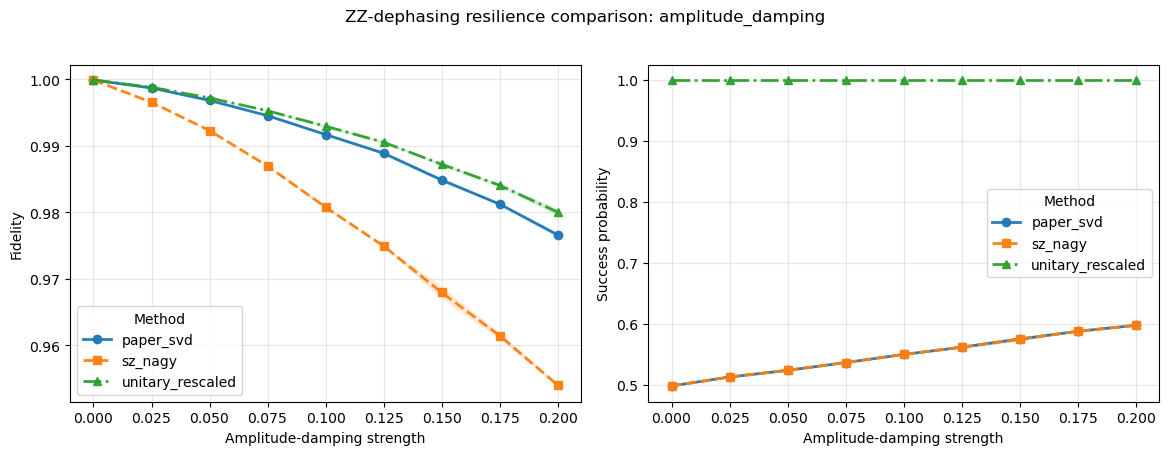

In [37]:
method_line_styles = {
    'paper_svd': '-',
    'sz_nagy': '--',
    'unitary_rescaled': '-.',
}

fig, axs = plot_method_comparison_dataframe(
    summary_results,
    method_column='method',
    columns=SweepPlotColumns(
        sweep_value='sweep_value',
        fidelity_mean='fidelity_mean',
        fidelity_std='fidelity_std',
        success_mean='success_probability_mean',
        success_std='success_probability_std',
    ),
    xlabel=default_sweep_xlabel(noise_kind),
    title=f'ZZ-dephasing resilience comparison: {noise_kind}',
    colors=['tab:blue', 'tab:orange', 'tab:green'],
    markers=['o', 's', '^'],
    line_styles=method_line_styles,
    legend_title='Method',
)
plt.show()

## Saves the figure

In [38]:
out_dir = Path.cwd()
fig.savefig(out_dir / 'zz_ampdamp_resilience.pdf', dpi=200, bbox_inches='tight')
plt.close(fig)